### Data Pre-processing & Transformation

In [1]:
%pip install Sastrawi
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install deep_translator
%pip install gensim
%pip install mittens

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import re
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction import text as sklearn_text

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

DATA_PATH = Path("dataset/ICAR_Text_Extracted.json")
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_K_FEATURES = 1000

USE_STEMMING = False

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for category, files in data.items():
    if isinstance(files, dict):
        for fname, txt in files.items():
            rows.append({
                "category": category,
                "doc_id": fname,
                "text_raw": str(txt) if txt is not None else ""
            })

df = pd.DataFrame(rows)
print("Jumlah dokumen:", len(df))
df.head()

Jumlah dokumen: 159


,category,doc_id,text_raw
0,Annual Reports,anrep-02003.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
1,Annual Reports,AR-2019-20.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,\n--- Page 1 ---\nWeb Url -https://icar.gov.in...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,\n--- Page 1 ---\nANNUAL REPORT 2018-19 or 04[...


In [4]:
stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")


def basic_cleaning(text: str) -> str:
    text = text.lower()                                  # lowercase
    text = url_pattern.sub(" ", text)                    # hapus URL
    text = digit_pattern.sub(" ", text)                  # hapus angka
    text = non_alpha_pattern.sub(" ", text)              # hapus tanda baca/simbol
    text = space_pattern.sub(" ", text).strip()          # rapikan spasi
    return text


@lru_cache(maxsize=100_000)
def stem_token(token: str) -> str:
    return STEMMER_ID.stem(token)


def normalize_text(text: str) -> str:
    if not USE_STEMMING or STEMMER_ID is None:
        return text
    tokens = text.split()
    return " ".join(stem_token(t) for t in tokens)


def remove_stopwords(text: str) -> str:
    tokens = [t for t in text.split() if t not in stopwords_all and len(t) > 2]
    return " ".join(tokens)


def preprocess_pipeline(text: str) -> str:
    text = basic_cleaning(text)
    text = normalize_text(text)
    text = remove_stopwords(text)
    return text

In [5]:
df["text_clean"] = df["text_raw"].apply(preprocess_pipeline)

print("Contoh hasil preprocessing:")
df[["category", "doc_id", "text_clean"]].head()

Contoh hasil preprocessing:


,category,doc_id,text_clean
0,Annual Reports,anrep-02003.pdf,page web url dare icar annual report departmen...
1,Annual Reports,AR-2019-20.pdf,page web url page indian council agricultvral ...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,page web url page indian council agricultural ...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,page web url page indian council agricultural ...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,page annual report taaa department agricultura...


## Back Translation — Data Augmentation untuk Class Balancing
Teknik **back translation** menerjemahkan teks **Indonesia → Inggris → Indonesia** untuk menghasilkan variasi teks baru.  
Digunakan untuk memperbanyak sampel pada **kelas minoritas** agar distribusi kelas lebih seimbang (balanced dataset).

In [6]:
import time
import random
from deep_translator import GoogleTranslator

In [7]:
def back_translate_id_en_id(text: str, delay: float = 0.5, max_chars: int = 4500) -> str:
    """
    Back translation pipeline:
      1. Indonesia -> English  (GoogleTranslator)
      2. English   -> Indonesia (GoogleTranslator)

    Args:
        text      : Teks input Bahasa Indonesia (sudah di-preprocess)
        delay     : Jeda antar request (detik) untuk menghindari rate-limit
        max_chars : Batas karakter agar tidak melebihi limit Google Translate
    Returns:
        Teks hasil back translation, atau teks asli jika terjadi error.
    """
    try:
        text = str(text).strip()[:max_chars]
        if not text:
            return text
        # Step 1: ID -> EN
        en_text = GoogleTranslator(source='id', target='en').translate(text)
        time.sleep(delay)
        # Step 2: EN -> ID
        id_text = GoogleTranslator(source='en', target='id').translate(en_text)
        return id_text
    except Exception as e:
        print(f"  [WARN] back_translate gagal: {e}")
        return text  # fallback ke teks asli

In [8]:
# Cek distribusi kelas SEBELUM augmentasi
print("=" * 55)
print("Distribusi kelas SEBELUM augmentasi:")
print("=" * 55)

class_dist = df['category'].value_counts().sort_values(ascending=False)
display(class_dist.to_frame('jumlah_dokumen'))

max_count = int(class_dist.max())
min_count = int(class_dist.min())

print(f"\nKelas terbanyak : {class_dist.idxmax()} ({max_count} dokumen)")
print(f"Kelas terdikit: {class_dist.idxmin()} ({min_count} dokumen)")
print(f"Rasio imbalance : {max_count / min_count:.2f}x")

Distribusi kelas SEBELUM augmentasi:


,jumlah_dokumen
category,
ÔüáBooks,54
ÔüáReports,47
Indian Farming,23
Indian Horticulture,18
Annual Reports,10
Traditional Knowledge in Agriculture,7



Kelas terbanyak : ÔüáBooks (54 dokumen)
Kelas terdikit: Traditional Knowledge in Agriculture (7 dokumen)
Rasio imbalance : 7.71x


In [9]:
# Back Translation Augmentation
# Strategi: semua kelas ditambah hingga = jumlah kelas terbanyak (max_count)

augmented_rows = []
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print("Proses augmentasi dimulai...\n")

for category, count in class_dist.items():
    needed = max_count - count

    if needed == 0:
        print(f"[SKIP] '{category}': sudah {count} dokumen — tidak perlu augmentasi")
        continue

    print(f"[AUG ] '{category}': {count} -> {max_count} dokumen ({needed} sampel baru)")

    cat_df  = df[df['category'] == category]
    samples = cat_df.sample(
        n=needed,
        replace=(needed > len(cat_df)),
        random_state=RANDOM_SEED
    )

    for i, (_, row) in enumerate(samples.iterrows()):
        new_text = back_translate_id_en_id(row['text_clean'])
        augmented_rows.append({
            'category'    : row['category'],
            'doc_id'      : f"{row['doc_id']}_aug{i + 1}",
            'text_raw'    : row['text_raw'],
            'text_clean'  : new_text,
            'is_augmented': True
        })

    print(f"  Selesai: {needed} sampel dihasilkan\n")

print("=" * 55)
print(f"Augmentasi selesai! Total baris baru: {len(augmented_rows)}")
print("=" * 55)

Proses augmentasi dimulai...

[SKIP] 'ÔüáBooks': sudah 54 dokumen — tidak perlu augmentasi
[AUG ] 'ÔüáReports': 47 -> 54 dokumen (7 sampel baru)
  Selesai: 7 sampel dihasilkan

[AUG ] 'Indian Farming': 23 -> 54 dokumen (31 sampel baru)
  Selesai: 31 sampel dihasilkan

[AUG ] 'Indian Horticulture': 18 -> 54 dokumen (36 sampel baru)
  Selesai: 36 sampel dihasilkan

[AUG ] 'Annual Reports': 10 -> 54 dokumen (44 sampel baru)
  Selesai: 44 sampel dihasilkan

[AUG ] 'Traditional Knowledge in Agriculture': 7 -> 54 dokumen (47 sampel baru)
  Selesai: 47 sampel dihasilkan

Augmentasi selesai! Total baris baru: 165


In [10]:
# Gabungkan data original + augmentasi
df_orig               = df.copy()
df_orig['is_augmented'] = False

df_aug = pd.concat(
    [df_orig, pd.DataFrame(augmented_rows)],
    ignore_index=True
)

class_dist_after = df_aug['category'].value_counts().sort_values(ascending=False)

print("=" * 55)
print("Distribusi kelas SESUDAH augmentasi:")
print("=" * 55)
display(class_dist_after.to_frame('jumlah_dokumen'))

print(f"\nTotal dokumen sebelum : {len(df)}")
print(f"Total dokumen sesudah : {len(df_aug)}")
print(f"Jumlah data augmentasi: {df_aug['is_augmented'].sum()}")

Distribusi kelas SESUDAH augmentasi:


,jumlah_dokumen
category,
Annual Reports,54
Indian Farming,54
Indian Horticulture,54
ÔüáBooks,54
ÔüáReports,54
Traditional Knowledge in Agriculture,54



Total dokumen sebelum : 159
Total dokumen sesudah : 324
Jumlah data augmentasi: 165


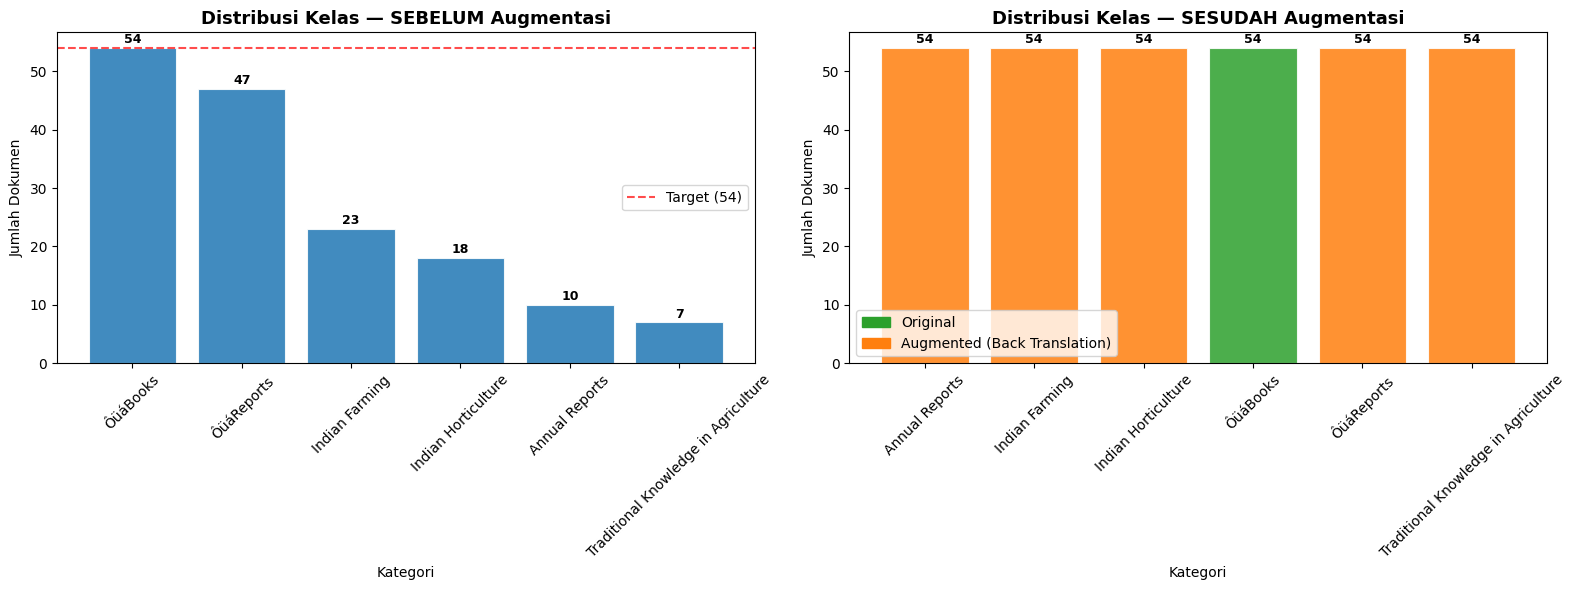

Grafik tersimpan: output/back_translation_augmentation.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BEFORE ---
axes[0].bar(class_dist.index, class_dist.values,
            color='#1f77b4', alpha=0.85, edgecolor='white', linewidth=0.8)
axes[0].axhline(y=max_count, color='red', linestyle='--', alpha=0.7,
                label=f'Target ({max_count})')
axes[0].set_title('Distribusi Kelas — SEBELUM Augmentasi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Dokumen')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
for bar, val in zip(axes[0].patches, class_dist.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- AFTER ---
aug_cats     = set(r['category'] for r in augmented_rows)
colors_after = ['#ff7f0e' if cat in aug_cats else '#2ca02c'
                for cat in class_dist_after.index]
axes[1].bar(class_dist_after.index, class_dist_after.values,
            color=colors_after, alpha=0.85, edgecolor='white', linewidth=0.8)
axes[1].set_title('Distribusi Kelas — SESUDAH Augmentasi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Dokumen')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[1].patches, class_dist_after.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
patch_orig = mpatches.Patch(color='#2ca02c', label='Original')
patch_aug  = mpatches.Patch(color='#ff7f0e', label='Augmented (Back Translation)')
axes[1].legend(handles=[patch_orig, patch_aug])

plt.tight_layout()
plt.savefig(OUT_DIR / 'back_translation_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafik tersimpan: {OUT_DIR / 'back_translation_augmentation.png'}")

In [12]:
# Preview contoh hasil back translation
print("Contoh hasil back translation:\n")
if augmented_rows:
    sample_preview = pd.DataFrame(augmented_rows).drop_duplicates('category').head(5)
    for _, row in sample_preview.iterrows():
        orig_text = df[df['category'] == row['category']]['text_clean'].iloc[0][:200]
        aug_text  = str(row['text_clean'])[:200]
        print(f"Kategori   : {row['category']}")
        print(f"Original   : {orig_text}...")
        print(f"Back-Trans : {aug_text}...")
        print("-" * 60)

# Simpan dataset augmentasi
aug_path = OUT_DIR / 'icar_augmented.csv'
df_aug[['category', 'doc_id', 'text_raw', 'text_clean', 'is_augmented']].to_csv(
    aug_path, index=False
)
print(f"\nDataset augmentasi tersimpan: {aug_path}")

Contoh hasil back translation:

Kategori   : ÔüáReports
Original   : page official use government india cid cid ministry agriculture farmers welfare cid cid cid chief controller accounts accounts glance page page accounts glance year government india ministry agriculut...
Back-Trans : halaman laporan penggunaan resmi manajemen komite kekuasaan tinggi krishi vigyan kendra kvk menyarankan langkah-langkah meningkatkan relevansi pedoman efisiensi implementasi hip icar divisi penyuluhan...
------------------------------------------------------------
Kategori   : Indian Farming
Original   : page website link page guidelines authors vlslt icar org inlindex phplilndfarm online submissions article alredy username password indian farming goto login need usernamc paaaword goto registration ae...
Back-Trans : halaman tautan situs web pedoman halaman penulis vlslt icar org inlindex phplilndfarm pengiriman online artikel sudah nama pengguna kata sandi pertanian India goto login perlu usernamc paaawo

## Word Embedding — Representasi Vektor Kata
Setelah augmentasi dengan **back translation**, dataset yang sudah seimbang digunakan untuk melatih model word embedding.
Tiga pendekatan yang diimplementasikan:
- **Word2Vec (Skip-gram)** — Mempelajari representasi kata berdasarkan konteks sekitarnya.
- **Word2Vec (CBOW)** — Memprediksi kata target dari konteks (mirip GloVe-style).
- **FastText** — Mempertimbangkan sub-kata (karakter n-gram) sehingga lebih robust untuk kata langka.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA
from pathlib import Path

print("Library word embedding berhasil dimuat.")

Library word embedding berhasil dimuat.


In [14]:
# === Load dataset augmentasi ===
# Gunakan df_aug jika tersedia dari sesi sebelumnya,
# atau load dari file CSV yang sudah disimpan.

try:
    _ = df_aug
    print(f"Menggunakan df_aug dari memori: {len(df_aug)} baris")
except NameError:
    aug_csv = Path("output") / "icar_augmented.csv"
    df_aug = pd.read_csv(aug_csv)
    print(f"Loaded dari {aug_csv}: {len(df_aug)} baris")

print("\nDistribusi kelas setelah augmentasi:")
display(df_aug['category'].value_counts().to_frame('jumlah'))

Menggunakan df_aug dari memori: 324 baris

Distribusi kelas setelah augmentasi:


,jumlah
category,
Annual Reports,54
Indian Farming,54
Indian Horticulture,54
ÔüáBooks,54
ÔüáReports,54
Traditional Knowledge in Agriculture,54


In [15]:
# === Tokenisasi ===
# Setiap dokumen (text_clean) di-split menjadi list token.

df_aug['text_clean'] = df_aug['text_clean'].fillna('')
sentences = [
    str(text).split()
    for text in df_aug['text_clean']
    if str(text).strip()
]

total_tokens = sum(len(s) for s in sentences)
vocab_approx = len({w for s in sentences for w in s})

print(f"Jumlah kalimat/dokumen : {len(sentences)}")
print(f"Total token            : {total_tokens:,}")
print(f"Ukuran vocab (approx)  : {vocab_approx:,}")

Jumlah kalimat/dokumen : 324
Total token            : 4,327,495
Ukuran vocab (approx)  : 110,234


In [16]:
# === Hyperparameter Word Embedding ===
VECTOR_SIZE = 100   # Dimensi vektor kata
WINDOW      = 5     # Ukuran konteks window
MIN_COUNT   = 2     # Abaikan kata yang muncul < min_count kali
EPOCHS      = 10    # Jumlah epoch pelatihan
WORKERS     = 4     # Thread paralel

print("Hyperparameter:")
print(f"  vector_size = {VECTOR_SIZE}")
print(f"  window      = {WINDOW}")
print(f"  min_count   = {MIN_COUNT}")
print(f"  epochs      = {EPOCHS}")

Hyperparameter:
  vector_size = 100
  window      = 5
  min_count   = 2
  epochs      = 10


In [17]:
# === Latih Word2Vec Skip-gram (sg=1) ===
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Melatih Word2Vec Skip-gram...")
w2v_sg = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    sg=1,          # 1 = Skip-gram
    epochs=EPOCHS,
    workers=WORKERS,
    seed=42
)

print(f"  Vocab size : {len(w2v_sg.wv):,}")
print(f"  Vector dim : {w2v_sg.vector_size}")
w2v_sg.save(str(OUT_DIR / "word2vec_skipgram.model"))
print("  Model tersimpan: output/word2vec_skipgram.model")

Melatih Word2Vec Skip-gram...
  Vocab size : 73,036
  Vector dim : 100
  Model tersimpan: output/word2vec_skipgram.model


In [18]:
# === Latih Word2Vec CBOW (sg=0) ===
print("Melatih Word2Vec CBOW...")
w2v_cbow = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    sg=0,          # 0 = CBOW
    epochs=EPOCHS,
    workers=WORKERS,
    seed=42
)

print(f"  Vocab size : {len(w2v_cbow.wv):,}")
w2v_cbow.save(str(OUT_DIR / "word2vec_cbow.model"))
print("  Model tersimpan: output/word2vec_cbow.model")

Melatih Word2Vec CBOW...
  Vocab size : 73,036
  Model tersimpan: output/word2vec_cbow.model


In [19]:
# === Latih FastText ===
print("Melatih FastText...")
ft = FastText(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    workers=WORKERS,
    seed=42
)

print(f"  Vocab size : {len(ft.wv):,}")
ft.save(str(OUT_DIR / "fasttext.model"))
print("  Model tersimpan: output/fasttext.model")

Melatih FastText...
  Vocab size : 73,036
  Model tersimpan: output/fasttext.model


In [ ]:
from mittens import GloVe
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Load data preprocessed
df_prep = pd.read_csv("output/icar_preprocessed.csv")
texts = df_prep["text_clean"].fillna("").tolist()

# Tokenisasi corpus
tokenized = [t.split() for t in texts]

# Bangun vocab dari corpus
vectorizer = CountVectorizer()
vectorizer.fit(texts)
vocab = vectorizer.get_feature_names_out().tolist()
word2id = {w: i for i, w in enumerate(vocab)}

# Bangun co-occurrence matrix
X_counts = vectorizer.transform(texts)
Xc = (X_counts.T @ X_counts).toarray().astype(float)

# Train GloVe
print(f"Vocab size: {len(vocab)}, Matrix shape: {Xc.shape}")
glove_model = GloVe(n=100, max_iter=100)
embeddings = glove_model.fit(Xc)

# Mapping kata -> vektor
word_vectors = {word: embeddings[i] for i, word in enumerate(vocab)}
print(f"Selesai. Contoh vektor '{vocab[0]}': {embeddings[0][:5]}")


In [ ]:
# === Evaluasi: Kata-kata paling mirip (Word2Vec SG / CBOW / FastText / GloVe) ===
PROBE_WORDS = ["agricultural", "research", "water", "yield", "soil"]

def print_similar_gensim(model, model_name, words, topn=5):
    print(f"\n{'='*55}")
    print(f"Model: {model_name}")
    print(f"{'='*55}")
    for w in words:
        try:
            similars = model.wv.most_similar(w, topn=topn)
            print(f"\n  '{w}' -> top {topn} similar:")
            for sw, sc in similars:
                print(f"    {sw:<20} {sc:.4f}")
        except KeyError:
            print(f"  '{w}' tidak ada dalam vocab.")

def print_similar_glove(model, model_name, words, topn=5):
    print(f"\n{'='*55}")
    print(f"Model: {model_name}")
    print(f"{'='*55}")
    for w in words:
        sims = glove_most_similar(model, w, topn=topn)
        if sims:
            print(f"\n  '{w}' -> top {topn} similar:")
            for sw, sc in sims:
                print(f"    {sw:<20} {sc:.4f}")
        else:
            print(f"  '{w}' tidak ada dalam vocab.")

print_similar_gensim(w2v_sg,   "Word2Vec Skip-gram", PROBE_WORDS)
print_similar_gensim(w2v_cbow, "Word2Vec CBOW",      PROBE_WORDS)
print_similar_gensim(ft,       "FastText",           PROBE_WORDS)
print_similar_glove(glove_model, "GloVe",            PROBE_WORDS)

In [ ]:
# === Visualisasi PCA Word Embedding (semua 4 model) ===
TOP_WORDS = 50

def visualize_embeddings_gensim(model, model_name, top_n=TOP_WORDS):
    words  = list(model.wv.key_to_index.keys())[:top_n]
    vecs   = np.array([model.wv[w] for w in words])
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs)
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=30)
    for i, word in enumerate(words):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.85)
    ax.set_title(f"PCA Word Embedding — {model_name} (Top {top_n} kata)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    plt.tight_layout()
    out_path = OUT_DIR / f"embedding_pca_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grafik tersimpan: {out_path}")

def visualize_embeddings_glove(model, model_name, top_n=TOP_WORDS):
    inv_dict = {v: k for k, v in model.dictionary.items()}
    indices  = list(range(min(top_n, len(model.dictionary))))
    words    = [inv_dict[i] for i in indices]
    vecs     = model.word_vectors[indices]
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs)
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=30)
    for i, word in enumerate(words):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.85)
    ax.set_title(f"PCA Word Embedding — {model_name} (Top {top_n} kata)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    plt.tight_layout()
    out_path = OUT_DIR / f"embedding_pca_{model_name.lower()}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grafik tersimpan: {out_path}")

visualize_embeddings_gensim(w2v_sg,   "Word2Vec Skip-gram")
visualize_embeddings_gensim(w2v_cbow, "Word2Vec CBOW")
visualize_embeddings_gensim(ft,       "FastText")
visualize_embeddings_glove(glove_model, "GloVe")

In [ ]:
# === Representasi Dokumen: rata-rata vektor kata (semua 4 model) ===

def doc_to_vec(model, tokens, vector_size):
    """Gensim: rata-rata vektor kata yang dikenal model."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

def doc_to_vec_glove(model, tokens, vector_size):
    """GloVe: rata-rata vektor kata yang ada di dictionary."""
    vecs = [
        model.word_vectors[model.dictionary[w]]
        for w in tokens if w in model.dictionary
    ]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

doc_vecs_sg    = np.array([doc_to_vec(w2v_sg,   s, VECTOR_SIZE) for s in sentences])
doc_vecs_cbow  = np.array([doc_to_vec(w2v_cbow, s, VECTOR_SIZE) for s in sentences])
doc_vecs_ft    = np.array([doc_to_vec(ft,       s, VECTOR_SIZE) for s in sentences])
doc_vecs_glove = np.array([doc_to_vec_glove(glove_model, s, VECTOR_SIZE) for s in sentences])

print("Shape doc-vector matrices:")
print(f"  Word2Vec Skip-gram : {doc_vecs_sg.shape}")
print(f"  Word2Vec CBOW      : {doc_vecs_cbow.shape}")
print(f"  FastText           : {doc_vecs_ft.shape}")
print(f"  GloVe              : {doc_vecs_glove.shape}")

# Simpan sebagai CSV
categories = df_aug['category'].values
for vecs, name in [
    (doc_vecs_sg,    "w2v_skipgram"),
    (doc_vecs_cbow,  "w2v_cbow"),
    (doc_vecs_ft,    "fasttext"),
    (doc_vecs_glove, "glove")
]:
    cols = [f"dim_{i}" for i in range(vecs.shape[1])]
    tmp  = pd.DataFrame(vecs, columns=cols)
    tmp.insert(0, "category", categories)
    path = OUT_DIR / f"doc_embeddings_{name}.csv"
    tmp.to_csv(path, index=False)
    print(f"  Tersimpan: {path}")

In [ ]:
# === Visualisasi PCA Doc-Vectors per Kategori (semua 4 model) ===

unique_cats = df_aug['category'].unique()
color_map   = plt.cm.get_cmap('tab10', len(unique_cats))
cat_colors  = {cat: color_map(i) for i, cat in enumerate(unique_cats)}

def visualize_doc_vecs(doc_vecs, categories, model_name):
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(doc_vecs)
    fig, ax = plt.subplots(figsize=(12, 8))
    for cat in unique_cats:
        idx = [i for i, c in enumerate(categories) if c == cat]
        ax.scatter(
            coords[idx, 0], coords[idx, 1],
            label=cat, alpha=0.7, s=20,
            color=cat_colors[cat]
        )
    ax.set_title(f"PCA Doc-Vectors per Kategori — {model_name}",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    ax.legend(fontsize=7, loc='best', ncol=2)
    plt.tight_layout()
    out_path = OUT_DIR / f"doc_pca_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grafik tersimpan: {out_path}")

visualize_doc_vecs(doc_vecs_sg,    categories, "Word2Vec Skip-gram")
visualize_doc_vecs(doc_vecs_cbow,  categories, "Word2Vec CBOW")
visualize_doc_vecs(doc_vecs_ft,    categories, "FastText")
visualize_doc_vecs(doc_vecs_glove, categories, "GloVe")

## Visualisasi Before vs After Preprocessing
Menampilkan perbandingan teks sebelum (`text_raw`) dan sesudah preprocessing (`text_clean`) secara kuantitatif (panjang karakter & token) dan kualitatif (contoh teks).

In [ ]:
import matplotlib.pyplot as plt

# Data ringkas before vs after
viz_df = df[["category", "doc_id", "text_raw", "text_clean"]].copy()
viz_df["len_raw"] = viz_df["text_raw"].str.len()
viz_df["len_clean"] = viz_df["text_clean"].str.len()
viz_df["tok_raw"] = viz_df["text_raw"].str.split().str.len()
viz_df["tok_clean"] = viz_df["text_clean"].str.split().str.len()

# 1) Contoh teks sebelum vs sesudah (dipotong agar rapi)
preview = viz_df[["category", "doc_id", "text_raw", "text_clean"]].head(5).copy()
preview["text_raw"] = preview["text_raw"].str.slice(0, 220) + "..."
preview["text_clean"] = preview["text_clean"].str.slice(0, 220) + "..."
print("Contoh before vs after (5 dokumen):")
display(preview)

# 2) Histogram panjang karakter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(viz_df["len_raw"], bins=25, alpha=0.7, color="#1f77b4", label="Before")
axes[0].hist(viz_df["len_clean"], bins=25, alpha=0.7, color="#ff7f0e", label="After")
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah karakter")
axes[0].set_ylabel("Jumlah dokumen")
axes[0].legend()

# 3) Histogram jumlah token
axes[1].hist(viz_df["tok_raw"], bins=25, alpha=0.7, color="#2ca02c", label="Before")
axes[1].hist(viz_df["tok_clean"], bins=25, alpha=0.7, color="#d62728", label="After")
axes[1].set_title("Distribusi Jumlah Token")
axes[1].set_xlabel("Jumlah token")
axes[1].set_ylabel("Jumlah dokumen")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4) Rata-rata pengurangan
char_reduction_pct = (1 - (viz_df["len_clean"].mean() / viz_df["len_raw"].mean())) * 100
tok_reduction_pct = (1 - (viz_df["tok_clean"].mean() / viz_df["tok_raw"].mean())) * 100

print(f"Rata-rata panjang karakter before: {viz_df['len_raw'].mean():.2f}")
print(f"Rata-rata panjang karakter after : {viz_df['len_clean'].mean():.2f}")
print(f"Pengurangan rata-rata karakter   : {char_reduction_pct:.2f}%")
print()
print(f"Rata-rata token before: {viz_df['tok_raw'].mean():.2f}")
print(f"Rata-rata token after : {viz_df['tok_clean'].mean():.2f}")
print(f"Pengurangan rata-rata token   : {tok_reduction_pct:.2f}%")

In [ ]:
# 5) Data transformation: TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(df["text_clean"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("Shape TF-IDF:", X.shape)
print("Jumlah fitur:", len(feature_names))

## Bag of Words + Visualisasi N-gram
Bagian ini membuat representasi **Bag of Words (BoW)** dan menampilkan n-gram teratas (unigram & bigram) berdasarkan frekuensi kemunculan kata.

In [ ]:
# 5.1) Bag of Words (BoW) + N-gram: Before vs After (tabel terpisah + per-feature)
# Before = text_raw, After = text_clean

# === BoW BEFORE (teks mentah) ===
bow_vectorizer_before = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow_before = bow_vectorizer_before.fit_transform(df["text_raw"].fillna(""))
bow_features_before = np.array(bow_vectorizer_before.get_feature_names_out())

term_counts_before = np.asarray(X_bow_before.sum(axis=0)).ravel()
ngram_before_df = pd.DataFrame({
    "feature": bow_features_before,
    "count_before": term_counts_before
})
ngram_before_df["n"] = ngram_before_df["feature"].str.split().str.len()

# === BoW AFTER (teks hasil preprocessing) ===
bow_vectorizer_after = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow = bow_vectorizer_after.fit_transform(df["text_clean"].fillna(""))
bow_feature_names = np.array(bow_vectorizer_after.get_feature_names_out())

term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
ngram_df = pd.DataFrame({
    "feature": bow_feature_names,
    "count_after": term_counts
})
ngram_df["n"] = ngram_df["feature"].str.split().str.len()

# === TABEL 1: Ringkasan Bag of Words ===
bow_compare_df = pd.DataFrame([
    {"Komponen": "Jumlah Fitur BoW", "Before": len(bow_features_before), "After": len(bow_feature_names)},
    {"Komponen": "Jumlah token non-zero (nnz)", "Before": int(X_bow_before.nnz), "After": int(X_bow.nnz)},
    {
        "Komponen": "Kerapatan matriks (%)",
        "Before": (X_bow_before.nnz / (X_bow_before.shape[0] * X_bow_before.shape[1])) * 100,
        "After": (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100
    }
])
bow_compare_df["Selisih (After-Before)"] = bow_compare_df["After"] - bow_compare_df["Before"]
bow_compare_df["Reduksi (%)"] = np.where(
    bow_compare_df["Before"] > 0,
    (1 - (bow_compare_df["After"] / bow_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - Bag of Words:")
display(bow_compare_df)

# === TABEL 2: Ringkasan N-gram ===
ngram_compare_df = pd.DataFrame([
    {"Komponen": "Unigram", "Before": int((ngram_before_df["n"] == 1).sum()), "After": int((ngram_df["n"] == 1).sum())},
    {"Komponen": "Bigram", "Before": int((ngram_before_df["n"] == 2).sum()), "After": int((ngram_df["n"] == 2).sum())}
])
ngram_compare_df["Selisih (After-Before)"] = ngram_compare_df["After"] - ngram_compare_df["Before"]
ngram_compare_df["Reduksi (%)"] = np.where(
    ngram_compare_df["Before"] > 0,
    (1 - (ngram_compare_df["After"] / ngram_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - N-gram:")
display(ngram_compare_df)

# === TABEL 3: Per-feature Before vs After ===
feature_compare_df = pd.merge(
    ngram_before_df[["feature", "n", "count_before"]],
    ngram_df[["feature", "n", "count_after"]],
    on="feature",
    how="outer",
    suffixes=("_before", "_after")
)

feature_compare_df["n"] = feature_compare_df["n_before"].fillna(feature_compare_df["n_after"]).astype(int)
feature_compare_df["count_before"] = feature_compare_df["count_before"].fillna(0).astype(int)
feature_compare_df["count_after"] = feature_compare_df["count_after"].fillna(0).astype(int)
feature_compare_df = feature_compare_df[["feature", "n", "count_before", "count_after"]]
feature_compare_df["selisih"] = feature_compare_df["count_after"] - feature_compare_df["count_before"]
feature_compare_df["perubahan_%"] = np.where(
    feature_compare_df["count_before"] > 0,
    ((feature_compare_df["count_after"] - feature_compare_df["count_before"]) / feature_compare_df["count_before"]) * 100,
    np.where(feature_compare_df["count_after"] > 0, 100.0, 0.0)
)

TOP_FEATURE_COMPARE = 20
per_feature_unigram = (
    feature_compare_df[feature_compare_df["n"] == 1]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)
per_feature_bigram = (
    feature_compare_df[feature_compare_df["n"] == 2]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Unigram:")
display(per_feature_unigram)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Bigram:")
display(per_feature_bigram)

# Simpan tabel lengkap per-feature agar bisa dicek semua fitur
per_feature_path = OUT_DIR / "icar_bow_ngram_per_feature_compare.csv"
feature_compare_df.sort_values(["n", "selisih"], ascending=[True, False]).to_csv(per_feature_path, index=False)
print("File per-feature tersimpan:", per_feature_path)

# === Top n-gram AFTER (opsional visualisasi) ===
TOP_SHOW = 15
unigram_top = feature_compare_df[feature_compare_df["n"] == 1].sort_values("count_after", ascending=False).head(TOP_SHOW)
bigram_top = feature_compare_df[feature_compare_df["n"] == 2].sort_values("count_after", ascending=False).head(TOP_SHOW)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(unigram_top["feature"][::-1], unigram_top["count_after"][::-1], color="#1f77b4")
axes[0].set_title(f"Top {len(unigram_top)} Unigram (After/BoW Count)")
axes[0].set_xlabel("Frekuensi")
axes[0].set_ylabel("Fitur")

axes[1].barh(bigram_top["feature"][::-1], bigram_top["count_after"][::-1], color="#ff7f0e")
axes[1].set_title(f"Top {len(bigram_top)} Bigram (After/BoW Count)")
axes[1].set_xlabel("Frekuensi")
axes[1].set_ylabel("Fitur")

plt.tight_layout()
plt.show()

In [ ]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)

print("Top 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

In [ ]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
removed_count = len(feature_names) - len(selected_features)
reduction_pct = (removed_count / len(feature_names)) * 100 if len(feature_names) > 0 else 0

compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)},
    {"Tahap": "Fitur terbuang", "Jumlah Fitur": removed_count}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)
print(f"Persentase reduksi fitur: {reduction_pct:.2f}%")

print("\nCatatan: Top-20 BEFORE dan AFTER bisa sama karena feature selection mengambil fitur dengan mean_tfidf tertinggi.")
print("Yang berubah adalah jumlah total fitur (dimensi), bukan ranking 20 teratas.")

print("\nTop 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

# Tampilkan contoh fitur yang DIBUANG agar perbedaan lebih terlihat
if removed_count > 0:
    removed_features_df = before_features_df.iloc[top_k:].copy()
    print("Contoh 20 fitur yang dibuang (bukan top-k):")
    display(removed_features_df.head(20))
else:
    print("Tidak ada fitur yang dibuang (top_k >= jumlah fitur awal).")

## 6.1 Visualisasi Before vs After: Transformation & Feature Selection
Visualisasi ini membandingkan kondisi **sebelum** (TF-IDF penuh) dan **sesudah** (TF-IDF tereduksi/top-k) pada proses transformasi dan seleksi fitur.

In [ ]:
# Ringkasan metrik before vs after
before_features = X.shape[1]
after_features = X_selected.shape[1]

before_density = X.nnz / (X.shape[0] * X.shape[1])
after_density = X_selected.nnz / (X_selected.shape[0] * X_selected.shape[1])

before_nnz_doc = np.asarray((X != 0).sum(axis=1)).ravel()
after_nnz_doc = np.asarray((X_selected != 0).sum(axis=1)).ravel()

summary_df = pd.DataFrame([
    {
        "Tahap": "Before (TF-IDF penuh)",
        "Jumlah Dokumen": X.shape[0],
        "Jumlah Fitur": before_features,
        "Rata-rata fitur non-zero/dokumen": before_nnz_doc.mean(),
        "Kerapatan Matriks (%)": before_density * 100
    },
    {
        "Tahap": "After (TF-IDF tereduksi)",
        "Jumlah Dokumen": X_selected.shape[0],
        "Jumlah Fitur": after_features,
        "Rata-rata fitur non-zero/dokumen": after_nnz_doc.mean(),
        "Kerapatan Matriks (%)": after_density * 100
    }
])

print("Ringkasan Before vs After:")
display(summary_df)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Jumlah fitur before vs after
axes[0, 0].bar(["Before", "After"], [before_features, after_features], color=["#1f77b4", "#ff7f0e"])
axes[0, 0].set_title("Jumlah Fitur: Before vs After")
axes[0, 0].set_ylabel("Jumlah fitur")

# 2) Kerapatan matriks before vs after
axes[0, 1].bar(["Before", "After"], [before_density * 100, after_density * 100], color=["#2ca02c", "#d62728"])
axes[0, 1].set_title("Kerapatan Matriks TF-IDF")
axes[0, 1].set_ylabel("Density (%)")

# 3) Distribusi skor mean TF-IDF (semua fitur = before selection)
axes[1, 0].hist(mean_scores, bins=30, color="#9467bd", alpha=0.8)
axes[1, 0].set_title("Distribusi Mean TF-IDF (Before Selection)")
axes[1, 0].set_xlabel("Mean TF-IDF")
axes[1, 0].set_ylabel("Jumlah fitur")

# 4) Top-k mean TF-IDF (after selection)
top_plot_k = min(30, len(selected_features))
top_names = selected_features[:top_plot_k]
top_vals = mean_scores[top_idx][:top_plot_k]

axes[1, 1].barh(top_names[::-1], top_vals[::-1], color="#17becf")
axes[1, 1].set_title(f"Top {top_plot_k} Fitur Terpilih (After Selection)")
axes[1, 1].set_xlabel("Mean TF-IDF")

plt.tight_layout()
plt.show()

# Persentase reduksi dimensi
reduction_pct = (1 - (after_features / before_features)) * 100
print(f"Reduksi jumlah fitur: {reduction_pct:.2f}%")

In [ ]:
# 7) Simpan hasil
preprocessed_path = OUT_DIR / "icar_preprocessed.csv"
features_path = OUT_DIR / "icar_selected_features.csv"
tfidf_selected_path = OUT_DIR / "icar_tfidf_selected.csv"

# a) Teks hasil preprocessing
df[["category", "doc_id", "text_clean"]].to_csv(preprocessed_path, index=False)

# b) Fitur terpilih
selected_df.to_csv(features_path, index=False)

# c) Matriks TF-IDF tereduksi
tfidf_df = pd.DataFrame(X_selected.toarray(), columns=selected_features)
tfidf_df.insert(0, "doc_id", df["doc_id"].values)
tfidf_df.to_csv(tfidf_selected_path, index=False)

print("Selesai disimpan:")
print("-", preprocessed_path)
print("-", features_path)
print("-", tfidf_selected_path)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np
from IPython.display import display

df_prep = pd.read_csv("output/icar_preprocessed.csv")
texts = df_prep["text_clean"].fillna("")
doc_ids = df_prep["doc_id"]

def show_ngram_and_matrix(texts, doc_ids, ngram_range, title, top_n=15):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")
    
    # 1. Feature Frequency Table
    vec_full = CountVectorizer(ngram_range=ngram_range)
    X_full = vec_full.fit_transform(texts)
    sum_words = X_full.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec_full.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    df_freq = pd.DataFrame(words_freq[:top_n], columns=["Feature", "Frekuensi"])
    print("\n1. Tabel Frekuensi Fitur (Top 15):")
    display(df_freq)
    
    # 2. Document-Term Matrix (using top N features)
    top_features = [w[0] for w in words_freq[:top_n]]
    # Sort alphabetically to match standard Vectorizer behavior
    top_features.sort()
    
    vec_matrix = CountVectorizer(ngram_range=ngram_range, vocabulary=top_features)
    X_matrix = vec_matrix.fit_transform(texts)
    
    df_matrix = pd.DataFrame(X_matrix.toarray(), columns=vec_matrix.get_feature_names_out())
    df_matrix.insert(0, "doc_id", doc_ids)
    
    print("\n2. Document-Term Matrix (Top 15 Fitur):")
    display(df_matrix.head(100))
    
    return top_features

# --- Eksekusi N-Gram ---
top_unigrams = show_ngram_and_matrix(texts, doc_ids, (1,1), "N-gram: ngram_range=(1,1) | Unigram | BoW (Bag of Words)")
show_ngram_and_matrix(texts, doc_ids, (2,2), "N-gram: ngram_range=(2,2) | Bigram")
top_uni_bi = show_ngram_and_matrix(texts, doc_ids, (1,2), "N-gram: ngram_range=(1,2) | Unigram + Bigram")


Data transformation (TF- IDF dengan ngram_range=(1,2)):
Tabel 2.1 Document-Term Matrix (IDF per dokumen).

In [ ]:
# Menggunakan top 15 fitur dari (1,2) N-gram untuk konsistensi tampilan
tfidf_vec = TfidfVectorizer(ngram_range=(1,2), vocabulary=top_uni_bi)
X_tfidf = tfidf_vec.fit_transform(texts)
feature_names = tfidf_vec.get_feature_names_out()

# 1. Tabel IDF per Fitur
idf_values = tfidf_vec.idf_
df_idf_features = pd.DataFrame({"Feature": feature_names, "IDF": idf_values})
print("1. IDF (Inverse Document Frequency) per Fitur:")
display(df_idf_features)

# 2. Document-Term Matrix (IDF per dokumen)
# Jika kata muncul di dokumen, tampilkan nilai IDF-nya, jika tidak = 0
count_vec = CountVectorizer(ngram_range=(1,2), vocabulary=top_uni_bi)
X_count = count_vec.fit_transform(texts)
X_idf_matrix = (X_count.toarray() > 0) * idf_values

df_idf_matrix = pd.DataFrame(X_idf_matrix, columns=feature_names)
df_idf_matrix.insert(0, "doc_id", doc_ids)

print("\n2. Tabel 2.1 Document-Term Matrix (IDF per dokumen):")
display(df_idf_matrix.head(100))

TF-IDF (Terms Frequency x Inverse Document Frequency):

In [ ]:
# Document-Term Matrix untuk TF-IDF
df_tfidf_matrix = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
df_tfidf_matrix.insert(0, "doc_id", doc_ids)

print("TF-IDF (Terms Frequency x Inverse Document Frequency):")
display(df_tfidf_matrix.head(100))

In [ ]:
import pandas as pd
from IPython.display import display
import re
from sklearn.feature_extraction import text as sklearn_text

# Definisi ulang pola jika belum ada
url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

# Ambil contoh teks pertama dari dataset awal untuk demonstrasi (karena df sudah ditimpa teks preprocessed)
import json
with open("dataset/ICAR_Text_Extracted.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)
    # Ambil nilai teks pertama yang ada
    for k, v in raw_data.items():
        if isinstance(v, dict):
            for fname, txt in v.items():
                if txt:
                    sample_text = str(txt)
                    break
        break

# 1. Case Folding
text_cf = sample_text.lower()
df_cf = pd.DataFrame([{"Before case Folding": sample_text, "After case Folding": text_cf}])

# 2. Remove URL
text_ru = url_pattern.sub(" ", text_cf)
df_ru = pd.DataFrame([{"Before remove URL": text_cf, "After remove URL": text_ru}])

# 3. Remove Non-Alphabet (Menghapus angka dan karakter selain alphabet)
text_rna = digit_pattern.sub(" ", text_ru)
text_rna = non_alpha_pattern.sub(" ", text_rna)
text_rna = non_alpha_pattern.sub(" ", text_rna)
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
text_nw = space_pattern.sub(" ", text_rna).strip()
df_nw = pd.DataFrame([{"Before normalize whitespace": text_rna, "After normalize whitespace": text_nw}])

# 5. Stopword Removal
tokens_sr = [t for t in text_nw.split() if t not in stopwords_all and len(t) > 2]
text_sr = " ".join(tokens_sr)
df_sr = pd.DataFrame([{"Before stopword removal": text_nw, "After stopword removal": text_sr}])

# 6. Stemming
if STEMMER_ID is not None:
    text_st = " ".join(STEMMER_ID.stem(t) for t in text_sr.split())
else:
    text_st = text_sr
df_st = pd.DataFrame([{"Before stemming": text_sr, "After stemming": text_st}])

print("1. Case Folding:")
display(df_cf)

print("\n2. Remove URL:")
display(df_ru)

print("\n3. Remove Non-Alphabet:")
display(df_rna)

print("\n4. Normalize Whitespace:")
display(df_nw)

print("\n5. Stopword Removal:")
display(df_sr)

print("\n6. Stemming:")
display(df_st)